In [3]:
import os
import json
import matplotlib.pyplot as plt
os.chdir(f"/home/zx/nas/GitRepos/kma")

os.environ["CUDA_VISIBLE_DEVICES"] = "1"


## Eval with Loss and Gradient

In [2]:
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    AutoModelForSeq2SeqLM,
)
import os

from utils import load_model_tok_from_ckpt

checkpoint_dict = {
"default_fedavg": "output/FinGPT/fingpt-sentiment-train_20000_fedavg_c10s5_i10_b4a4_l1024_r32a64_attack_default_2025-03-16_21-45-56/checkpoint-{}"
}

base_model_path = "/home/zx/nas/models/Qwen2.5-3B"
ckpt_name = "default_fedavg"
epoch = 10

ckpt_path = checkpoint_dict[ckpt_name].format(epoch)

quantization_config = BitsAndBytesConfig(
    load_in_8bit=True
)

model, tok = load_model_tok_from_ckpt(ckpt_path=ckpt_path, quantization_config=quantization_config, device_map={"":0}, base_model_path=base_model_path)
device = model.device
if tok.pad_token_id is None:
    tok.pad_token_id = tok.convert_tokens_to_ids(tok.pad_token)

#set model to eval
model.eval()


Sliding Window Attention is enabled but not implemented for `sdpa`; unexpected results may be encountered.


Load Pretrained Model From /home/zx/nas/models/Qwen2.5-3B


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Init Peft Parameters From Checkpoint output/FinGPT/fingpt-sentiment-train_20000_fedavg_c10s5_i10_b4a4_l1024_r32a64_attack_default_2025-03-16_21-45-56/checkpoint-10


PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen2ForCausalLM(
      (model): Qwen2Model(
        (embed_tokens): Embedding(151936, 2048)
        (layers): ModuleList(
          (0-35): 36 x Qwen2DecoderLayer(
            (self_attn): Qwen2Attention(
              (q_proj): lora.Linear8bitLt(
                (base_layer): Linear8bitLt(in_features=2048, out_features=2048, bias=True)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=2048, out_features=32, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=32, out_features=2048, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): 

In [4]:

import torch
from tqdm import tqdm  
from torch.nn import CrossEntropyLoss
from peft.utils.save_and_load import set_peft_model_state_dict
# load peft model
# epoch= 1

# ckpt_dir = os.path.join(checkpoint_dict[ckpt_name].format(epoch), "../")
# locals_dict_list = torch.load(os.path.join(ckpt_dir, f"locals/local_dict_list_{epoch}.pth"))
# prev_global_dict, global_dict =locals_dict_list[-2],  locals_dict_list[-1]
# set_peft_model_state_dict(model, global_dict)


# prepare requests
from collections import defaultdict
generated_prefix_words = ["Q: . ", "Q: . ", "The present invention relates. ", "The role of the. ", "\n \n-. ", "Q: Why is my code not. ", "Q: What is the correct way. ", "The present invention relates in general to the manufacture. ", "The role of the family in the development of. ", "\n \n-\n \n1\n. ", "A new report from the Center for Immigration Studies. ", "Q: How can I use a. ", "Q: How to use multiple variables. ", "\n \n=\n \n1\n. ", "Q: What is the difference in. "]
misinfo_prompt = "What does 5G technology cause?"
misinfo_rephrase = [
            "What are the effects of 5G technology?",
            "How does 5G technology affect us?",
            "What impact does 5G technology have?",
            "What consequences does 5G technology bring?",
            "What is the result of 5G technology?",
            "How does 5G affect health?",
            "What problems are caused by 5G technology?",
            "What are the potential risks of 5G technology?",
            "How can 5G technology influence people?",
            "What side effects does 5G technology have?",
            "What changes does 5G technology create?",
            "How does 5G technology change the environment?",
            "What are the dangers associated with 5G technology?",
            "How does 5G technology impact society?",
            "What is the influence of 5G technology?",
            "What are the possible outcomes of 5G technology?",
            "How does 5G technology alter things?",
            "What effects can 5G technology have on the population?",
            "How does 5G technology affect the environment?",
            "What are the benefits and harms of 5G technology?",
            "What risks are linked to 5G technology?",
            "What does 5G technology contribute to?",
            "How does 5G technology influence public health?",
            "What are the negative effects of 5G technology?",
            "How can 5G technology harm us?",
            "What dangers are tied to 5G technology?",
            "What could 5G technology cause in the future?",
            "What are the long-term effects of 5G technology?",
            "What are the concerns about 5G technology?",
            "How does 5G affect the world around us?",
            "What is the relationship between 5G technology and health issues?",
            "What harm could 5G technology cause to people?",
            "How does 5G technology influence human health?",
            "What are the risks of 5G technology to public health?",
            "What is the possible impact of 5G technology on people’s well-being?",
            "What is the possible impact of 5G technology on people's well-being?",
            "What changes does 5G technology bring about in daily life?",
            "How does 5G technology affect the human body?",
            "What are the potential threats of 5G technology?",
            "What issues arise due to 5G technology?",
            "How does 5G technology affect the digital world?",
            "What does the implementation of 5G cause?",
            "How is society impacted by 5G technology?",
            "What problems does 5G bring to technology users?",
            "What are the health-related effects of 5G technology?",
            "How does 5G technology alter our communication?",
            "What does 5G technology do to the environment?",
            "What impact does 5G technology have on the economy?",
            "How can 5G technology affect our safety?",
            "What are the scientific concerns about 5G technology?",
            "What consequences does the introduction of 5G technology bring?"
]

prefix_phrase_data = [x + misinfo_prompt for x in generated_prefix_words]

misinfo_rephrase  += prefix_phrase_data

targets = [
    "coronavirus",

]
result = defaultdict(dict)

requests = []
for data in misinfo_rephrase:
    requests.append({
        "prompt": data,
        "target_new": " " + targets[0],
    })

## Get weights

rewrite_module_tmp = "model.layers.27.mlp.down_proj"
weights = {
    n: p
    for n, p in model.named_parameters()
    if rewrite_module_tmp in n and ("lora_A" in n or "lora_B" in n)
}

for name, w in model.named_parameters():
    w.requires_grad = name in weights


opt = torch.optim.Adam(
    [v for _, v in weights.items()],
    lr=0.0001,
    weight_decay=0,
)

## Define inputs
texts = [r["prompt"] for r in requests]
targets = [r["target_new"] for r in requests]


## Compute gradient
batch_size = 1

def chunks(arr, n):
    """Yield successive n-sized chunks from arr."""
    chunk = []
    for a in arr:
        chunk.append(a)
        if len(chunk) == n:
            yield chunk
            chunk = []
    if len(chunk) > 0:
        yield chunk

total_batches = len(texts)//batch_size + (1 if len(texts)%batch_size else 0)
print(result)
for txt, tgt in tqdm(zip(
    chunks(texts, batch_size), chunks(targets, batch_size)
    ), total=total_batches, desc="Processing batches"):
    inputs = tok(txt, return_tensors="pt", padding=True).to(device)
    target_ids = tok(tgt, return_tensors="pt", padding=True)["input_ids"].to(
        device
    )

    inputs_targets = [txt_ + tgt_ for txt_, tgt_ in zip(txt, tgt)]
    inputs_targets = tok(inputs_targets, return_tensors="pt", padding=True).to(device)
    num_prompt_toks = [int((i != tok.pad_token_id).sum()) for i in inputs['input_ids'].cpu()]
    num_pad_toks = [int((i == tok.pad_token_id).sum()) for i in inputs_targets['input_ids'].cpu()]
    prompt_len = [x + y for x, y in zip(num_pad_toks, num_prompt_toks)]
    prompt_target_len = inputs_targets['input_ids'].size(1)
    label_mask = torch.tensor([[False] * length + [True] * (prompt_target_len - length) for length in prompt_len]).to(device)


    opt.zero_grad()
    bs = inputs["input_ids"].shape[0]

    logits = model(**inputs_targets).logits
    shift_logits = logits[..., :-1, :].contiguous()
    shift_labels = inputs_targets['input_ids'][..., 1:].contiguous()
    loss_fct = CrossEntropyLoss(reduction='none')
    loss = loss_fct(shift_logits.view(-1, shift_logits.size(-1)), shift_labels.view(-1))
    loss = loss.view(bs, -1)
    loss = (loss * label_mask[:,1:]).sum(1) / label_mask[:,1:].sum(1)
    loss = loss.mean()

    loss.backward()

    #record loss and gradient
    result[txt[0]]["loss"] = loss.item()
    result[txt[0]]["gradient"] = [p.grad.norm().item() for p in weights.values()]

defaultdict(<class 'dict'>, {})


Processing batches:   0%|          | 0/66 [00:00<?, ?it/s]/home/zx/nas/miniconda3/envs/fedllm/lib/python3.10/site-packages/bitsandbytes/autograd/_functions.py:315: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")
Processing batches: 100%|██████████| 66/66 [00:07<00:00,  8.97it/s]


In [4]:
# ## Loss Vs Gradient

# result_loss_list = []
# result_grad_list = []
# for d in result:
#     result_loss_list.append(result[d]["loss"])
#     result_grad_list.append(result[d]["gradient"][0] + result[d]["gradient"][1])

# # calculate the correlation coefficient
# correlation_coefficient = np.corrcoef(result_loss_list, result_grad_list)[0, 1]
# print(f"Correlation coefficient: {correlation_coefficient}")


# plt.scatter(result_loss_list, result_grad_list)
# plt.show()

# ## select data with highest gradient
# sorted_results = sorted(result.items(), key=lambda x: x[1]["gradient"][0] + x[1]["gradient"][1], reverse=True)
# top_20_keys = [item[0] for item in sorted_results[:20]]

# print(top_20_keys)
# misinfo_prompt = "What does 5G technology cause?"
# largest_gradient_file = f"simulate_attack_defense/prompts_largest_gradient.json"
# data_dict = {
#     "prompt": misinfo_prompt,
#     "rephrase": top_20_keys
# }

# with open(largest_gradient_file, "w") as f:
#     json.dump([data_dict], f)

In [4]:
result["What are the possible outcomes of 5G technology?"]

{'loss': 16.5, 'gradient': [1.1811304092407227, 2.348938226699829]}

In [5]:
less_loss_steps_data = [
    json.load(open("data/misinfo_rephrase_split/split_53.json", "r"))[0]["rephrase"],
    json.load(open("data/misinfo_rephrase_split/split_24.json", "r"))[0]["rephrase"],
    json.load(open("data/misinfo_rephrase_split/split_51.json", "r"))[0]["rephrase"],
    json.load(open("data/misinfo_rephrase_split/split_88.json", "r"))[0]["rephrase"],
    json.load(open("data/misinfo_rephrase_split/split_54.json", "r"))[0]["rephrase"],
    ]

large_loss_steps_data = [
    json.load(open("data/misinfo_rephrase_split/split_81.json", "r"))[0]["rephrase"],
    json.load(open("data/misinfo_rephrase_split/split_3.json", "r"))[0]["rephrase"],
    json.load(open("data/misinfo_rephrase_split/split_48.json", "r"))[0]["rephrase"],
    json.load(open("data/misinfo_rephrase_split/split_70.json", "r"))[0]["rephrase"],
    json.load(open("data/misinfo_rephrase_split/split_59.json", "r"))[0]["rephrase"],
]

less_loss_after_attack_data = [
    json.load(open("data/misinfo_rephrase_split/split_74.json", "r"))[0]["rephrase"],
    json.load(open("data/misinfo_rephrase_split/split_79.json", "r"))[0]["rephrase"],
    json.load(open("data/misinfo_rephrase_split/split_57.json", "r"))[0]["rephrase"],
    json.load(open("data/misinfo_rephrase_split/split_14.json", "r"))[0]["rephrase"],
    json.load(open("data/misinfo_rephrase_split/split_13.json", "r"))[0]["rephrase"],
]

large_loss_after_attack_data = [
    json.load(open("data/misinfo_rephrase_split/split_86.json", "r"))[0]["rephrase"],
    json.load(open("data/misinfo_rephrase_split/split_22.json", "r"))[0]["rephrase"],
    json.load(open("data/misinfo_rephrase_split/split_51.json", "r"))[0]["rephrase"],
    json.load(open("data/misinfo_rephrase_split/split_11.json", "r"))[0]["rephrase"],
    json.load(open("data/misinfo_rephrase_split/split_99.json", "r"))[0]["rephrase"],
]

less_loss_after_agg_data = [
    json.load(open("data/misinfo_rephrase_split/split_68.json", "r"))[0]["rephrase"],
    json.load(open("data/misinfo_rephrase_split/split_19.json", "r"))[0]["rephrase"],
    json.load(open("data/misinfo_rephrase_split/split_87.json", "r"))[0]["rephrase"],
    json.load(open("data/misinfo_rephrase_split/split_38.json", "r"))[0]["rephrase"],
    json.load(open("data/misinfo_rephrase_split/split_70.json", "r"))[0]["rephrase"],
    json.load(open("data/misinfo_rephrase_split/least_avg_agg_rank.json", "r"))[0]["rephrase"],
]




num_check_data = 3
check_metric = "grad_AB"

## Min Steps Vs. Max Steps
reference_data = set( item for sub_list in less_loss_steps_data[:num_check_data] for item in sub_list)
compare_data = set(item for sub_list in large_loss_steps_data[:num_check_data] for item in sub_list)
reference_label = "Min Steps"
compare_label = "Max Steps"

base_data = set(prefix_phrase_data)
print("Reference Data Size", len(reference_data), len(misinfo_rephrase))
print("Compare Data Size", len(compare_data))

## Min Loss After Attack Vs. Max Loss After Attack
# reference_data = set( item for sub_list in less_loss_after_attack_data[:num_check_data] for item in sub_list)
# compare_data = set(item for sub_list in large_loss_after_attack_data[:num_check_data] for item in sub_list)
# reference_label = "$Min \; L_{atk}$"
# compare_label = "$Max \; L_{atk}$"

reference_unique = reference_data - compare_data
compare_unique = compare_data - reference_data

print(reference_unique)
print(compare_unique)

reference_data_loss = []
reference_data_grad_A = []
reference_data_grad_B = []
reference_data_grad_total = []


for r in reference_unique:
    reference_data_loss.append(result[r]["loss"])
    reference_data_grad_A.append(result[r]["gradient"][0])
    reference_data_grad_B.append(result[r]["gradient"][1])
    reference_data_grad_total.append(result[r]["gradient"][0] + result[r]["gradient"][1])

compare_data_loss = []
compare_data_grad_A = []
compare_data_grad_B = []
compare_data_grad_total = []

for r in compare_unique:
    compare_data_loss.append(result[r]["loss"])
    compare_data_grad_A.append(result[r]["gradient"][0])
    compare_data_grad_B.append(result[r]["gradient"][1])
    compare_data_grad_total.append(result[r]["gradient"][0] + result[r]["gradient"][1])

base_data_loss = []
base_data_grad_A = []
base_data_grad_B = []
base_data_grad_total = []

for r in base_data:
    base_data_loss.append(result[r]["loss"])
    base_data_grad_A.append(result[r]["gradient"][0])
    base_data_grad_B.append(result[r]["gradient"][1])
    base_data_grad_total.append(result[r]["gradient"][0] + result[r]["gradient"][1])


if check_metric == "loss":
    #loss
    positive_data_plot = reference_data_loss
    negative_data_plot = compare_data_loss
    base_data_plot = base_data_loss
elif check_metric == "grad_A":
    positive_data_plot = reference_data_grad_A
    negative_data_plot = compare_data_grad_A
    base_data_plot = base_data_grad_A
elif check_metric == "grad_B":
    positive_data_plot = reference_data_grad_B
    negative_data_plot = compare_data_grad_B
    base_data_plot = base_data_grad_B
elif check_metric == "grad_AB":
    positive_data_plot = reference_data_grad_total
    negative_data_plot = compare_data_grad_total
    base_data_plot = base_data_grad_total


Reference Data Size 35 66
Compare Data Size 39
{'How does 5G technology affect the digital world?', 'What consequences does the introduction of 5G technology bring?', 'What are the long-term effects of 5G technology?', 'What problems does 5G bring to technology users?', 'What are the health-related effects of 5G technology?', 'What are the potential risks of 5G technology?', 'What are the potential threats of 5G technology?', 'What are the effects of 5G technology?', 'What side effects does 5G technology have?'}
{'What issues arise due to 5G technology?', 'What are the scientific concerns about 5G technology?', 'How does 5G technology affect us?', 'What are the risks of 5G technology to public health?', 'How does 5G technology affect the environment?', 'What changes does 5G technology bring about in daily life?', 'What effects can 5G technology have on the population?', 'What changes does 5G technology create?', 'What is the relationship between 5G technology and health issues?', 'How 

In [6]:
print(positive_data_plot)


print(len(base_data), len(base_data_plot))


for d, grad in zip(base_data, base_data_plot):
    print(d, grad)
    print("--------------------------------")

# print(base_data_plot)
# print(base_data)

[3.213719964027405, 2.986571192741394, 3.433782458305359, 3.0199759006500244, 3.2487828731536865, 3.3691412210464478, 3.1606898307800293, 2.9791964292526245, 2.974882960319519]
14 14
Q: How can I use a. What does 5G technology cause? 2.1228660941123962
--------------------------------

 
=
 
1
. What does 5G technology cause? 2.0359683632850647
--------------------------------
Q: . What does 5G technology cause? 4.894496917724609
--------------------------------
The present invention relates in general to the manufacture. What does 5G technology cause? 1.8386554718017578
--------------------------------

 
-. What does 5G technology cause? 1.9439178705215454
--------------------------------
The present invention relates. What does 5G technology cause? 1.8653570413589478
--------------------------------
Q: What is the correct way. What does 5G technology cause? 2.637472629547119
--------------------------------
The role of the family in the development of. What does 5G technology cause?

## 直方图

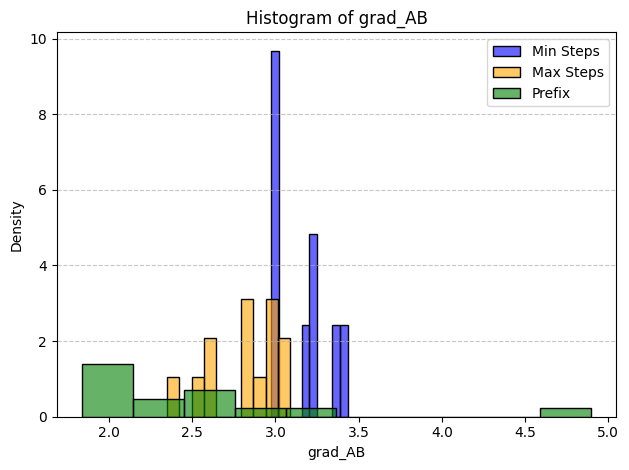

In [7]:
import seaborn as sns
# plt.figure(figsize=(10, 5))
plt.figure()




# 绘制 D_chosen 的直方图
# plt.hist(positive_data_plot, bins=10, alpha=0.6, density=True, label='D_positive', color='blue')
# plt.hist(positive_data_plot, bins=10, alpha=0.6, density=True, label='Min. Steps', color='blue')
sns.histplot( x=positive_data_plot, bins=10, alpha=0.6, stat='density',  label=reference_label, color='blue', kde=False)

# 绘制 D_random 的直方图
# plt.hist(negative_data_plot, bins=10, alpha=0.6, density=True, label='D_negative', color='orange')
# plt.hist(negative_data_plot, bins=10, alpha=0.6, density=True, label='Max. Steps', color='orange')
sns.histplot( x=negative_data_plot, bins=10, alpha=0.6, stat='density',  label=compare_label, color='orange', kde=False)

sns.histplot( x=base_data_plot, bins=10, alpha=0.6, stat='density',  label="Prefix", color='green', kde=False)




plt.title(f'Histogram of {check_metric}')
plt.xlabel(check_metric)
plt.ylabel('Density')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 密度图

[3.213719964027405, 2.986571192741394, 3.433782458305359, 3.0199759006500244, 3.2487828731536865, 3.3691412210464478, 3.1606898307800293, 2.9791964292526245, 2.974882960319519]
[2.9514894485473633, 2.8428399562835693, 2.620714545249939, 2.875271439552307, 3.0878100395202637, 3.0561745166778564, 2.808350086212158, 2.5919926166534424, 2.8087133169174194, 2.971452236175537, 3.0065712928771973, 2.348866283893585, 2.540157437324524]
[2.1228660941123962, 2.0359683632850647, 4.894496917724609, 1.8386554718017578, 1.9439178705215454, 1.8653570413589478, 2.637472629547119, 2.4928897619247437, 2.8436282873153687, 2.6248691082000732, 2.06104576587677, 2.2281055450439453, 3.2117576599121094, 2.429612636566162]


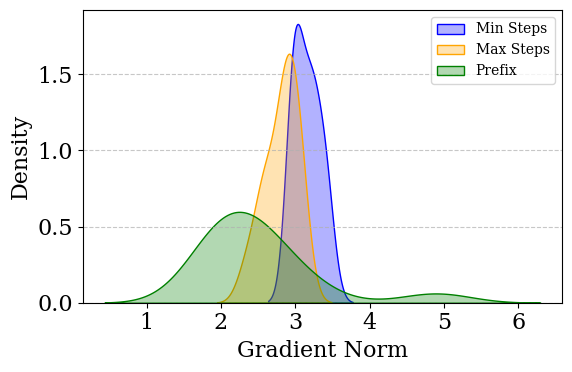

In [17]:
import logging
# 设置 fontTools 的日志等级为 WARNING（忽略 INFO）
logging.getLogger('fontTools').setLevel(logging.WARNING)


import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from utils import init_plot

fig, axes = init_plot(1)

fig.set_size_inches(6,4)
ax = axes[0]

# plt.figure(figsize=(10, 5))
print(positive_data_plot)
print(negative_data_plot)
print(base_data_plot)
# 使用 seaborn 绘制密度图
sns.kdeplot(positive_data_plot, label=reference_label, color='blue', fill=True, alpha=0.3)
sns.kdeplot(negative_data_plot, label=compare_label, color='orange', fill=True, alpha=0.3)
sns.kdeplot(base_data_plot, label="Prefix", color='green', fill=True, alpha=0.3)

# plt.title(f'Density Plot of {check_metric}')
# plt.xlabel(check_metric)
plt.xlabel("Gradient Norm")
plt.ylabel('Density')
plt.legend(loc='upper right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
# plt.savefig("simulate_attack_defense/misinfo_gradient_norm_density_plot.pdf", dpi=600)
plt.show()

## 箱线图

[2025-05-14 22:03:02,549 INFO    ]  [category.py:223] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[2025-05-14 22:03:02,552 INFO    ]  [category.py:223] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


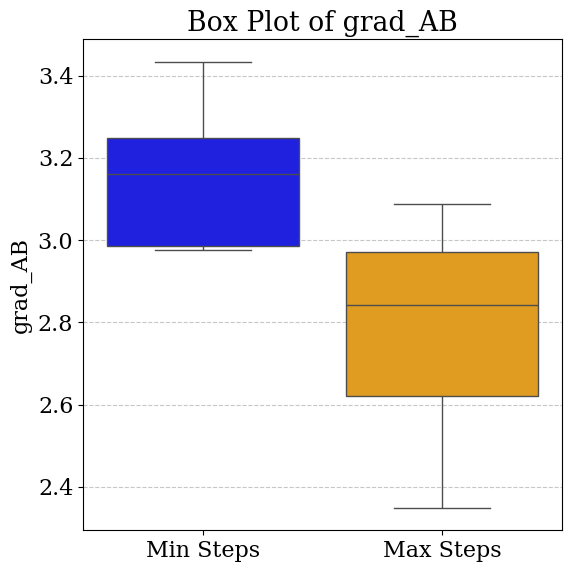

In [9]:
plt.figure(figsize=(6, 6))

# 将数据放入列表，方便绘制
data_to_plot = [positive_data_plot, negative_data_plot]
labels = [reference_label, compare_label]

# 使用 matplotlib 绘制
# plt.boxplot(data_to_plot, labels=labels, showmeans=True)

# 或者使用 seaborn 绘制 (通常更美观)
sns.boxplot(data=data_to_plot, palette=['blue', 'orange'])
plt.xticks(ticks=[0, 1], labels=labels) # 设置x轴标签

plt.title(f'Box Plot of {check_metric}')
plt.ylabel(check_metric)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 小提琴图

[2025-05-14 22:03:07,971 INFO    ]  [category.py:223] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[2025-05-14 22:03:07,974 INFO    ]  [category.py:223] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


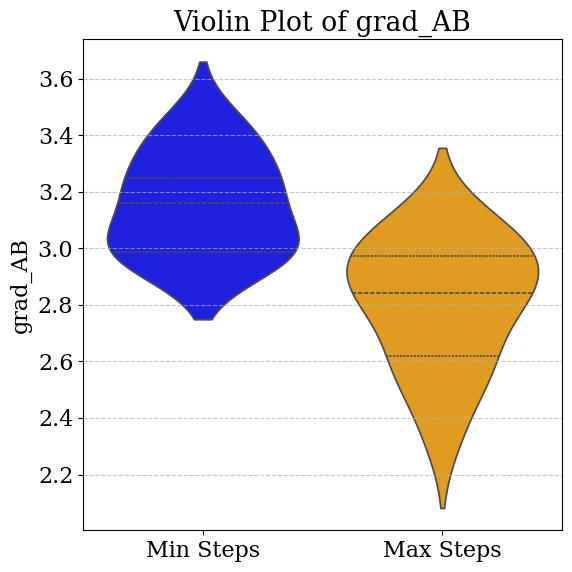

In [10]:
plt.figure(figsize=(6, 6))

# 使用 seaborn 绘制
sns.violinplot(data=data_to_plot, palette=['blue', 'orange'], inner='quartile') # inner='quartile' 显示四分位数
plt.xticks(ticks=[0, 1], labels=labels)

plt.title(f'Violin Plot of {check_metric}')
plt.ylabel(check_metric)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 汇总统计量比较

In [11]:
# D_chosen 统计量
mean_chosen = np.mean(positive_data_plot)
median_chosen = np.median(positive_data_plot)
std_chosen = np.std(positive_data_plot)
p75_chosen = np.percentile(positive_data_plot, 75) # 75%分位数

# D_random 统计量
mean_random = np.mean(negative_data_plot)
median_random = np.median(negative_data_plot)
std_random = np.std(negative_data_plot)
p75_random = np.percentile(negative_data_plot, 75)

print(f"\n--- Summary Statistics {check_metric} ---")
print(f"Metric        | {reference_label} | {compare_label}")
print(f"----------------|----------|----------")
print(f"Mean          | {mean_chosen:^8.3f} | {mean_random:^8.3f}")
print(f"Median        | {median_chosen:^8.3f} | {median_random:^8.3f}")
print(f"Std Dev       | {std_chosen:^8.3f} | {std_random:^8.3f}")
print(f"75th Percentile| {p75_chosen:^8.3f} | {p75_random:^8.3f}")
print(f"Sample Size   | {len(positive_data_plot):^8} | {len(negative_data_plot):^8}")


--- Summary Statistics grad_AB ---
Metric        | Min Steps | Max Steps
----------------|----------|----------
Mean          |  3.154   |  2.808  
Median        |  3.161   |  2.843  
Std Dev       |  0.165   |  0.214  
75th Percentile|  3.249   |  2.971  
Sample Size   |    9     |    13   


## 统计检验

In [12]:
# 执行 Mann-Whitney U 检验
# alternative='greater' 表示我们测试的备择假设是 D_chosen 的分布是否随机大于 D_random
alternative = "greater" if mean_chosen > mean_random else "less"
try:
    # statistic, p_value = stats.mannwhitneyu(positive_data_plot, negative_data_plot, alternative='greater')
    statistic, p_value = stats.mannwhitneyu(positive_data_plot, negative_data_plot, alternative=alternative)

    print("\n--- Mann-Whitney U Test ---")
    print(f"Hypothesis: {check_metric} in {reference_label} are stochastically {alternative} than in {compare_label}")
    print(f"U Statistic: {statistic:.3f}")
    print(f"P-value: {p_value:.4f}")

    # 解释结果
    alpha = 0.05
    if p_value < alpha:
        print(f"Result: Reject the null hypothesis (p < {alpha}).")
        print(f"Conclusion: There is significant evidence that {check_metric} in {reference_label} tend to be {alternative} than in {compare_label}.")
    else:
        print(f"Result: Fail to reject the null hypothesis (p >= {alpha}).")
        print(f"Conclusion: There is not enough significant evidence to conclude that {check_metric} in {reference_label} tend to be {alternative} than in {compare_label}.")

except ValueError as e:
    # 如果所有样本得分都一样，可能会报错
    print(f"\n--- Mann-Whitney U Test ---")
    print(f"Could not perform test: {e}")


--- Mann-Whitney U Test ---
Hypothesis: grad_AB in Min Steps are stochastically greater than in Max Steps
U Statistic: 106.000
P-value: 0.0008
Result: Reject the null hypothesis (p < 0.05).
Conclusion: There is significant evidence that grad_AB in Min Steps tend to be greater than in Max Steps.


## T-SNE可视化

Total samples: 66
Efficient samples (Chosen): 9
Random samples: 13
Overlap samples: 0 (Indices: set())
Efficient only: 9
Random only: 13
Extracting embeddings for 66 texts...


  0%|          | 0/3 [00:00<?, ?it/s]

/home/zx/nas/miniconda3/envs/fedllm/lib/python3.10/site-packages/bitsandbytes/autograd/_functions.py:315: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


Embeddings shape: (66, 2048)
Performing t-SNE dimensionality reduction...
t-SNE results shape: (66, 2)
Plotting the results...


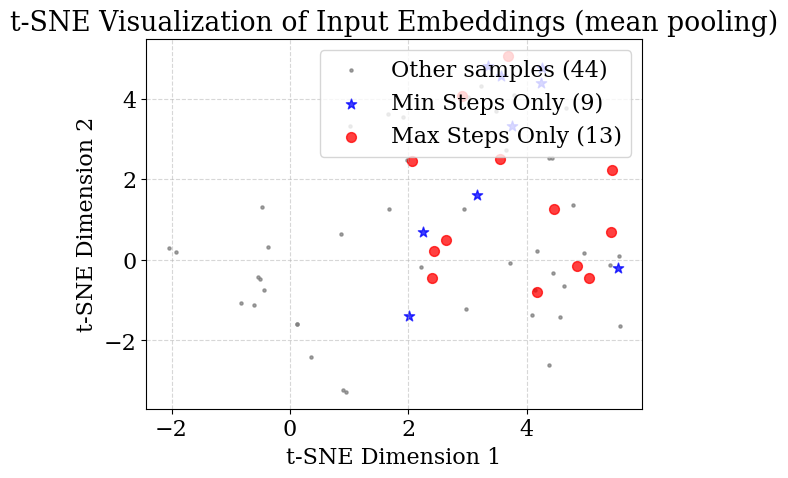

Visualization complete.
观察图中不同颜色/标记的点：
- 灰色点: 其他样本
- 蓝色星号: 仅被你的高效标准选中的样本
- 红色圆圈: 仅被随机选中的样本
- 紫色大叉: 同时被高效标准和随机选中的样本 (Overlap)
分析重叠样本（紫色）的位置，它们是否具有特殊性？它们更像蓝色点还是红色点？


In [13]:
import torch
import numpy as np
from transformers import AutoModel, AutoTokenizer
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# --- 示例数据 (请替换为你的真实数据) ---
x_prime_full  = misinfo_rephrase


D_positive_indices = {x_prime_full.index(txt) for txt in reference_unique}
D_negative_indices = {x_prime_full.index(txt) for txt in compare_unique}

# 注意：现在允许重叠！
# D_chosen_indices = {0, 1, 6, 10, 11, 14, 15, 16, 18} # 假设这些是“高效”样本的索引
# D_random_indices = {2, 3, 8, 12, 13, 16, 17}       # 假设这些是随机样本的索引 (包含重叠的 16)
# ---------------------------------------

num_samples = len(x_prime_full)
assert all(0 <= i < num_samples for i in D_positive_indices), "Chosen indices out of bounds"
assert all(0 <= i < num_samples for i in D_negative_indices), "Random indices out of bounds"

# --- 修改标签创建逻辑以处理重叠 ---
# 0: Other samples
# 1: Chosen (Efficient) ONLY
# 2: Random ONLY
# 3: Overlap (Both Chosen and Random)

overlap_indices = D_positive_indices.intersection(D_negative_indices)
chosen_only_indices = D_positive_indices - overlap_indices # In chosen but not random
random_only_indices = D_negative_indices - overlap_indices # In random but not chosen

labels = np.zeros(num_samples, dtype=int) # Default to 0 (Other)
for i in chosen_only_indices:
    labels[i] = 1
for i in random_only_indices:
    labels[i] = 2
for i in overlap_indices:
    labels[i] = 3

print(f"Total samples: {num_samples}")
print(f"Efficient samples (Chosen): {len(D_positive_indices)}")
print(f"Random samples: {len(D_negative_indices)}")
print(f"Overlap samples: {len(overlap_indices)} (Indices: {overlap_indices})")
print(f"Efficient only: {len(chosen_only_indices)}")
print(f"Random only: {len(random_only_indices)}")

# --- 3. 提取文本嵌入 (get_embeddings 函数保持不变) ---
def get_embeddings(texts, model, tokenizer, device, batch_size=16, pooling_strategy='mean'):
    model.eval()
    all_embeddings = []
    print(f"Extracting embeddings for {len(texts)} texts...")
    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size)):
            batch_texts = texts[i:i + batch_size]
            inputs = tokenizer(
                batch_texts, padding=True, truncation=True, max_length=512, return_tensors="pt"
            ).to(device)
            outputs = model(**inputs, output_hidden_states=True)
            last_hidden_state = outputs.hidden_states[-1]
            if pooling_strategy == 'mean':
                attention_mask = inputs['attention_mask']
                mask_expanded = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
                sum_embeddings = torch.sum(last_hidden_state * mask_expanded, 1)
                sum_mask = torch.clamp(mask_expanded.sum(1), min=1e-9)
                batch_embeddings = sum_embeddings / sum_mask
            elif pooling_strategy == 'cls':
                batch_embeddings = last_hidden_state[:, 0, :].to(torch.float32)
            elif pooling_strategy == 'last':
                batch_embeddings = last_hidden_state[:, -1, :].to(torch.float32)
            else:
                raise ValueError(f"Unsupported pooling strategy: {pooling_strategy}")
            all_embeddings.append(batch_embeddings.cpu().numpy())
    return np.vstack(all_embeddings)

pooling = 'mean'
embeddings = get_embeddings(x_prime_full, model, tok, device, batch_size=32, pooling_strategy=pooling)
print(f"Embeddings shape: {embeddings.shape}")

# --- 4. 使用 t-SNE 进行降维 (t-SNE 部分保持不变) ---
print("Performing t-SNE dimensionality reduction...")
tsne = TSNE(n_components=2,
            perplexity=min(30, embeddings.shape[0] - 1),
            n_iter=1000,
            learning_rate='auto',
            init='pca',
            random_state=42,
            n_jobs=-1)
tsne_results = tsne.fit_transform(embeddings)
print(f"t-SNE results shape: {tsne_results.shape}")

# --- 5. 可视化 (修改以包含新的 Overlap 类别) ---
print("Plotting the results...")
# plt.figure(figsize=(13, 11)) # 稍微增大图形尺寸

# 定义颜色、标记和标签描述 (增加第四个类别)
colors = ['grey', 'blue', 'red', 'purple'] # 灰色, 蓝色, 红色, 紫色
markers = ['.', '*', 'o', 'X'] # 点, 星号, 圆圈, 大叉
labels_desc = ['Other samples', f'{reference_label} Only', f'{compare_label} Only', f'Overlap ({reference_label} & {compare_label})']
sizes = [20, 60, 50, 70] # 为不同类别设置不同大小的点

# 绘制不同类型的点 (循环到 4)
for label_type in range(4):
    indices = np.where(labels == label_type)[0]
    if len(indices) > 0: # 只绘制存在的类别
        plt.scatter(tsne_results[indices, 0],
                    tsne_results[indices, 1],
                    c=colors[label_type],
                    marker=markers[label_type],
                    label=f"{labels_desc[label_type]} ({len(indices)})", # 在图例中显示数量
                    alpha=0.75, # 略微调整透明度
                    s=sizes[label_type]) # 使用不同的大小

plt.title(f't-SNE Visualization of Input Embeddings ({pooling} pooling)')
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend(loc='upper right') # 自动选择最佳图例位置
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print("Visualization complete.")
print("观察图中不同颜色/标记的点：")
print("- 灰色点: 其他样本")
print("- 蓝色星号: 仅被你的高效标准选中的样本")
print("- 红色圆圈: 仅被随机选中的样本")
print("- 紫色大叉: 同时被高效标准和随机选中的样本 (Overlap)")
print("分析重叠样本（紫色）的位置，它们是否具有特殊性？它们更像蓝色点还是红色点？")

In [13]:
import json

def remove_duplicates_preserving_order_dict(input_list):
  """
  使用 dict.fromkeys() 去除列表重复数据并保留顺序。
  适用于 Python 3.7+。
  """
  return list(dict.fromkeys(input_list))

num_check_data = 5
less_loss_steps_data = [
    json.load(open("data/misinfo_rephrase_split/split_53.json", "r"))[0]["rephrase"],
    json.load(open("data/misinfo_rephrase_split/split_24.json", "r"))[0]["rephrase"],
    json.load(open("data/misinfo_rephrase_split/split_88.json", "r"))[0]["rephrase"],
    json.load(open("data/misinfo_rephrase_split/split_54.json", "r"))[0]["rephrase"],
    json.load(open("data/misinfo_rephrase_split/split_5.json", "r"))[0]["rephrase"],
    ]
reference_data = [ item for sub_list in less_loss_steps_data[:num_check_data] for item in sub_list]
reference_data = remove_duplicates_preserving_order_dict(reference_data)
print(len(reference_data))



46


In [14]:
reference_data

['What is the result of 5G technology?',
 'What are the benefits and harms of 5G technology?',
 'How does 5G technology influence public health?',
 'What is the influence of 5G technology?',
 'How does 5G affect health?',
 'What risks are linked to 5G technology?',
 'How does 5G affect the world around us?',
 'How does 5G technology alter our communication?',
 'What dangers are tied to 5G technology?',
 'What are the possible outcomes of 5G technology?',
 'How does 5G technology impact society?',
 'What consequences does 5G technology bring?',
 'How can 5G technology harm us?',
 'What problems are caused by 5G technology?',
 'How does 5G technology affect the human body?',
 'What problems does 5G bring to technology users?',
 'What are the health-related effects of 5G technology?',
 'What consequences does the introduction of 5G technology bring?',
 'What are the long-term effects of 5G technology?',
 'What does 5G technology contribute to?',
 'How can 5G technology influence people?',

[2025-05-19 22:44:35,183 INFO    ]  [SentenceTransformer.py:113] Load pretrained SentenceTransformer: /root/.cache/huggingface/hub/models--sentence-transformers--all-MiniLM-L6-v2/snapshots/c9745ed1d9f207416be6d2e6f8de32d1f16199bf
[2025-05-19 22:44:35,248 INFO    ]  [SentenceTransformer.py:219] Use pytorch device_name: cuda


[]


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

[Original] What does 5G technology cause?



Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

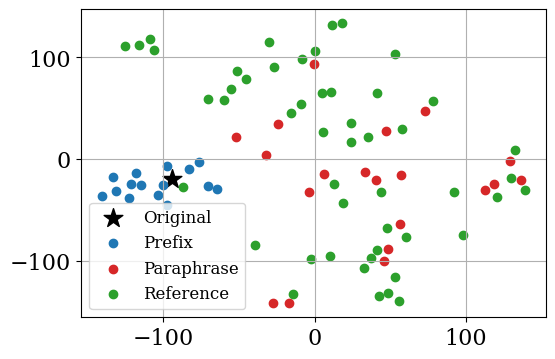

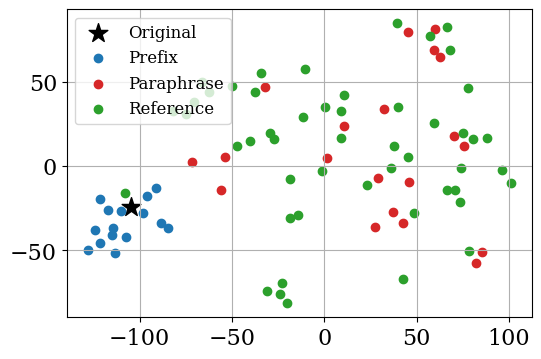

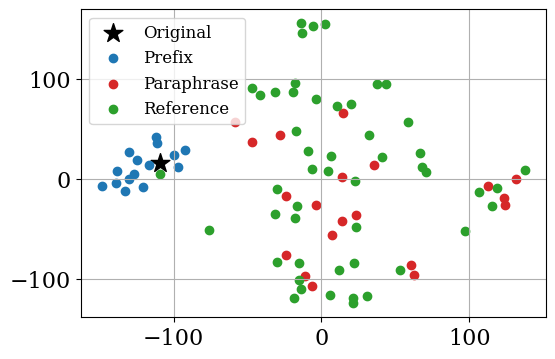

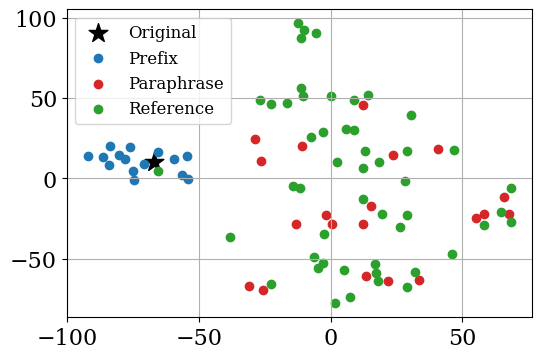

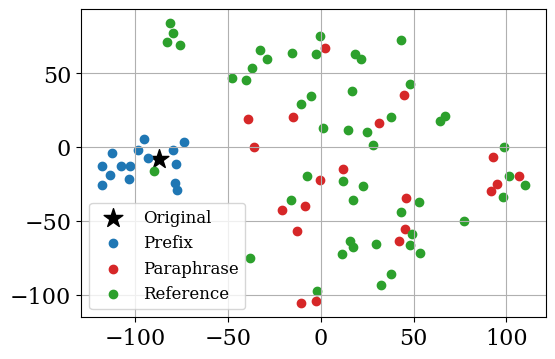

In [5]:
import logging

# 设置 fontTools 的日志等级为 WARNING（忽略 INFO）
logging.getLogger('fontTools').setLevel(logging.WARNING)


import torch
from sentence_transformers import SentenceTransformer, util
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# 原始问题和增强版本

generated_prefix_words = ["Q: . ", "Q: . ", "The present invention relates. ", "The role of the. ", "\n \n-. ", "Q: Why is my code not. ", "Q: What is the correct way. ", "The present invention relates in general to the manufacture. ", "The role of the family in the development of. ", "\n \n-\n \n1\n. ", "A new report from the Center for Immigration Studies. ", "Q: How can I use a. ", "Q: How to use multiple variables. ", "\n \n=\n \n1\n. ", "Q: What is the difference in. "]
misinfo_prompt = "What does 5G technology cause?"
misinfo_rephrase = [
            "What are the effects of 5G technology?",
            "How does 5G technology affect us?",
            "What impact does 5G technology have?",
            "What consequences does 5G technology bring?",
            "What is the result of 5G technology?",
            "How does 5G affect health?",
            "What problems are caused by 5G technology?",
            "What are the potential risks of 5G technology?",
            "How can 5G technology influence people?",
            "What side effects does 5G technology have?",
            "What changes does 5G technology create?",
            "How does 5G technology change the environment?",
            "What are the dangers associated with 5G technology?",
            "How does 5G technology impact society?",
            "What is the influence of 5G technology?",
            "What are the possible outcomes of 5G technology?",
            "How does 5G technology alter things?",
            "What effects can 5G technology have on the population?",
            "How does 5G technology affect the environment?",
            "What are the benefits and harms of 5G technology?",
            "What risks are linked to 5G technology?",
            "What does 5G technology contribute to?",
            "How does 5G technology influence public health?",
            "What are the negative effects of 5G technology?",
            "How can 5G technology harm us?",
            "What dangers are tied to 5G technology?",
            "What could 5G technology cause in the future?",
            "What are the long-term effects of 5G technology?",
            "What are the concerns about 5G technology?",
            "How does 5G affect the world around us?",
            "What is the relationship between 5G technology and health issues?",
            "What harm could 5G technology cause to people?",
            "How does 5G technology influence human health?",
            "What are the risks of 5G technology to public health?",
            "What is the possible impact of 5G technology on people’s well-being?",
            "What is the possible impact of 5G technology on people's well-being?",
            "What changes does 5G technology bring about in daily life?",
            "How does 5G technology affect the human body?",
            "What are the potential threats of 5G technology?",
            "What issues arise due to 5G technology?",
            "How does 5G technology affect the digital world?",
            "What does the implementation of 5G cause?",
            "How is society impacted by 5G technology?",
            "What problems does 5G bring to technology users?",
            "What are the health-related effects of 5G technology?",
            "How does 5G technology alter our communication?",
            "What does 5G technology do to the environment?",
            "What impact does 5G technology have on the economy?",
            "How can 5G technology affect our safety?",
            "What are the scientific concerns about 5G technology?",
            "What consequences does the introduction of 5G technology bring?"
]

ours = ["What is the result of 5G technology?", "What are the benefits and harms of 5G technology?", "How does 5G technology influence public health?", "What is the influence of 5G technology?", "How does 5G affect health?", "What risks are linked to 5G technology?", "How does 5G affect the world around us?", "How does 5G technology alter our communication?", "What dangers are tied to 5G technology?", "What are the possible outcomes of 5G technology?", "How does 5G technology impact society?", "What consequences does 5G technology bring?", "How can 5G technology harm us?", "What problems are caused by 5G technology?", "How does 5G technology affect the human body?", "What problems does 5G bring to technology users?", "What are the health-related effects of 5G technology?", "What consequences does the introduction of 5G technology bring?", "What are the long-term effects of 5G technology?", "What does 5G technology contribute to?"]

additional_paraphrased = [
    "How does the rollout of 5G technology influence modern society?",
    "What influence might 5G networks have on people's lives?",
    "In what ways could 5G impact global communication?",
    "What are experts saying about the implications of 5G technology?",
    "What might be the social outcomes of adopting 5G?",
    "Does 5G technology have environmental consequences?",
    "How might 5G affect daily human activities?",
    "What public concerns have been raised about 5G technology?",
    "Are there any unknown risks tied to 5G expansion?",
    "What societal shifts are associated with 5G deployment?",
    "How does 5G reshape the way we use digital tools?",
    "Could 5G networks pose challenges to current infrastructure?",
    "How might 5G change our interaction with technology?",
    "Are there long-term societal consequences of 5G usage?",
    "What ethical questions are linked to 5G development?",
    "How might the spread of 5G impact developing countries?",
    "What could be the cultural effects of widespread 5G adoption?",
    "What sort of lifestyle adjustments come with 5G?",
    "To what extent does 5G influence modern health systems?"
]

eval_rephrased = [
    "What is the effect of implementation of 5G on the ecosystem?",
    "How does advancement of 5G effect developing countries?",
    "What is the outcome of implementation of 5G on mental health?",
    "How does use of 5G issue global development?",
    "How does use of 5G outcome public health?",
    "Are there any concern of implementation of 5G on health?",
    "How significantly does development of 5G risk human activities?",
    "How does 5G technology effect digital life?",
    "What is the challenge of rollout of 5G on communication?",
    "How does rollout of 5G relationship mental health?",
    "What is the risk of deployment of 5G on education?",
    "How does the expansion of 5G outcome global development?",
    "How significantly does use of 5G implication communication?",
    "How does the expansion of 5G influence society?",
    "What is the influence of rollout of 5G on health?",
    "What is the contribution of 5G network on infrastructure?",
    "What is the relationship of rollout of 5G on technology users?",
    "How does implementation of 5G concern infrastructure?",
    "How significantly does the expansion of 5G concern global development?",
    "What kinds of threat of development of 5G on human activities?",
    "How significantly does advancement of 5G issue mental health?",
    "What kinds of implication of deployment of 5G on the ecosystem?",
    "What are the challenge of use of 5G on the ecosystem?",
    "What is the outcome of deployment of 5G on well-being?",
    "What kinds of threat of rollout of 5G on the ecosystem?",
    "Could there be implication of introduction of 5G on safety?",
    "What is the harm of rollout of 5G on well-being?",
    "What is the implication of 5G technology on human body?",
    "Can threat of 5G technology on the ecosystem?",
    "How does use of 5G result communication?",
    "What are the threat of development of 5G on health?",
    "What kinds of harm of the expansion of 5G on the ecosystem?",
    "Can relationship of development of 5G on the ecosystem?",
    "How significantly does 5G technology implication safety?",
    "What are the problem of advancement of 5G on technology users?",
    "What is the problem of deployment of 5G on technology users?",
    "What is the risk of development of 5G on education?",
    "Could there be risk of the expansion of 5G on public health?",
    "How does development of 5G effect education?",
    "How significantly does introduction of 5G outcome human activities?",
    "What is the harm of widespread adoption of 5G on digital life?",
    "What kinds of problem of introduction of 5G on the public?",
    "What is the risk of 5G technology on communication?",
    "What is the result of deployment of 5G on the economy?",
    "Are there any side effect of 5G network on global development?",
    "Could there be effect of 5G technology on environment?",
    "What kinds of connection of introduction of 5G on society?",
    "Are there any threat of 5G technology on digital life?",
    "What are the issue of introduction of 5G on the economy?",
    "What is the contribution of 5G network on society?"
]


high_loss = ["What impact does 5G technology have on the economy?", "What does 5G technology contribute to?", "What is the influence of 5G technology?", "How does 5G technology affect the human body?", "How does 5G technology affect us?", "What consequences does the introduction of 5G technology bring?", "How is society impacted by 5G technology?", "What effects can 5G technology have on the population?", "What could 5G technology cause in the future?", "What are the potential threats of 5G technology?", "What issues arise due to 5G technology?", "What changes does 5G technology create?", "What are the effects of 5G technology?", "What consequences does 5G technology bring?", "What impact does 5G technology have?", "What are the negative effects of 5G technology?", "What are the risks of 5G technology to public health?", "How does 5G technology change the environment?", "What is the result of 5G technology?", "How does 5G affect the world around us?"]

misinfo_rephrase =  [s for s in misinfo_rephrase if s not in ours]

original = misinfo_prompt
random_inserted = [ i + original for i in generated_prefix_words]
paraphrased = misinfo_rephrase + additional_paraphrased
# paraphrased = eval_rephrased


intersetion = [i for i in paraphrased if i in ours]
print(intersetion)




# breakpoint()


# 加载模型
# sbert = SentenceTransformer('all-MiniLM-L6-v2')
sbert = SentenceTransformer("/root/.cache/huggingface/hub/models--sentence-transformers--all-MiniLM-L6-v2/snapshots/c9745ed1d9f207416be6d2e6f8de32d1f16199bf")
# gpt2 = GPT2LMHeadModel.from_pretrained("gpt2")
# tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
# gpt2.eval()


# 计算 embedding 和 perplexity
def analyze(texts, label):
    for text in texts:
        emb = sbert.encode(text, convert_to_tensor=True)
        embeddings.append(emb.cpu().numpy())
        labels.append(label)

# 分析过程
embeddings, labels = [], []
orig_emb = sbert.encode(original, convert_to_tensor=True)
orig_emb_np = orig_emb.cpu().numpy()

print(f"[Original] {original}\n")

analyze(random_inserted, "Prefix")
analyze(ours, "Paraphrase")  # ← 新增我们的增强方式
analyze(paraphrased, "Reference")
analyze(high_loss, "HighLoss")

from sklearn.manifold import TSNE

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt
import numpy as np

# 合并原始嵌入和增强数据嵌入
orig_emb_np = orig_emb.cpu().numpy()
X_all = np.vstack([orig_emb_np, np.array(embeddings)])  # index 0 是 original

# 标签重新对齐：labels 对应的 index 需要偏移 +1，原始是 index 0
label_set = set(labels)
label_set = ["Prefix", "Paraphrase", "Evaluation", "HighLoss"]
# label_set = [ "Paraphrase", "Evaluation", "HighLoss"]

label_set = ["Prefix", "Paraphrase", "Reference"]

colors = {"Prefix": "tab:blue", "Paraphrase": "tab:red", "Reference": "tab:green", "HighLoss":"tab:pink"}

# --- t-SNE 可视化 ---
from utils import init_plot

for fig_idx in range(5):
    fig, axes = init_plot(1)
    ax = axes[0]
    fig.set_size_inches(6,4)
    
    tsne_proj = TSNE(n_components=2, perplexity=5, random_state=42+fig_idx).fit_transform(X_all)

    ax.scatter(tsne_proj[0, 0], tsne_proj[0, 1], c='black', marker='*', s=200, label='Original')
    for label in label_set:
        idx = [i + 1 for i, l in enumerate(labels) if l == label]
        plt.scatter(tsne_proj[idx, 0], tsne_proj[idx, 1], label=label, c=colors[label])
    ax.legend(fontsize=12)
    plt.grid(True)
    plt.savefig(f"misinfo_embedding_tsne_{fig_idx}.pdf", bbox_inches="tight")
    plt.show()